# Intervention Impact Analysis
## Dropout Risk Assessment Before & After 6-Month Interventions

This notebook compares students' dropout risk predictions before interventions with their predicted risk after 6 months of receiving extra lectures/support.

**Objective**: Measure intervention effectiveness by analyzing changes in:
- Dropout risk probability
- Classification changes (High Risk → Low Risk, etc.)
- Feature improvements contributing to risk reduction

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Data Loading & Setup

In [14]:
# Define paths
BASE_PATH = Path('/home/oriol-ms/IA-Universitat/PAID/PAID-Lab/PW234-PAID-2026-T6-StudentDropout')
DATA_PATH = BASE_PATH / 'Data'
MODELS_PATH = BASE_PATH / 'Models'
INTERVENTION_DATA_PATH = BASE_PATH / 'InterventionData'  # New folder for intervention tracking

# Create intervention data directory if it doesn't exist
INTERVENTION_DATA_PATH.mkdir(exist_ok=True)

# Load preprocessed student data (baseline/pre-intervention)
print("Loading baseline student data...")
df_baseline = pd.read_csv(DATA_PATH / 'student_preprocessed.csv')
print(f"Baseline data shape: {df_baseline.shape}")
print(f"Columns: {df_baseline.columns.tolist()}")
print(f"\nDropout class distribution (baseline):\n{df_baseline['dropout'].value_counts()}")

Loading baseline student data...
Baseline data shape: (6607, 21)
Columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'dropout']

Dropout class distribution (baseline):
dropout
0    5288
1    1319
Name: count, dtype: int64


## 2. Identify Intervention Recipients

Students receiving interventions are those identified as at-risk (dropout = 1) in baseline assessment.

In [15]:
# Add student_id from original dataset
df_baseline['student_id'] = range(len(df_baseline))

# Identify at-risk students (intervention recipients)
df_intervention_recipients = df_baseline[df_baseline['dropout'] == 1].copy()

print(f"✓ Intervention recipients identified: {len(df_intervention_recipients)} students")
print(f"\nIntervention recipients:")
print(df_intervention_recipients.head())

print(f"\nSample statistics (intervention group):")
print(df_intervention_recipients.describe())

✓ Intervention recipients identified: 1319 students

Intervention recipients:
    Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
1              19          64                  Low              Medium   
14             10          78               Medium                High   
16             14          60               Medium                 Low   
19             12          75               Medium                High   
24             17          65                  Low                High   

    Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
1                            0            8               59              Low   
14                           1            8               74           Medium   
16                           1           10               65              Low   
19                           1            7               58           Medium   
24                           1            5               75           M

## 3. Select Students for Analysis

Select 50 students from the intervention recipients for the analysis period (before & after comparison).

In [16]:
# ⭐ REALISTIC SCENARIO: Select 50 students for analysis
# These are the students selected for the questionnaire after 6 months
sample_size = 50
print(f"Selecting {sample_size} students from {len(df_intervention_recipients)} intervention recipients...")
print("(These are the students selected for the 6-month questionnaire)\n")

df_questionnaire_sample = df_intervention_recipients.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"✓ Selected {len(df_questionnaire_sample)} students for questionnaire")
print(f"  Student IDs (original): {df_questionnaire_sample['student_id'].tolist()[:10]}...")
df_questionnaire_sample

Selecting 50 students from 1319 intervention recipients...
(These are the students selected for the 6-month questionnaire)

✓ Selected 50 students for questionnaire
  Student IDs (original): [3491, 5268, 3175, 259, 6416, 2556, 2886, 4747, 381, 2661]...


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,dropout,student_id
0,19,69,Medium,Medium,1,7,55,Low,1,1,...,Public,Positive,4,0,College,Near,Female,63,1,3491
1,12,68,High,Medium,1,6,68,Low,1,2,...,Public,Positive,4,0,College,Near,Male,64,1,5268
2,15,71,High,High,0,7,100,Low,1,2,...,Public,Neutral,4,0,High School,Near,Male,66,1,3175
3,25,69,Medium,Medium,1,7,70,Low,0,1,...,Public,Positive,4,0,High School,Far,Female,65,1,259
4,12,72,Medium,Medium,0,7,67,Low,1,0,...,Public,Positive,2,0,High School,Near,Female,61,1,6416
5,4,62,Medium,Medium,0,6,78,High,1,3,...,Public,Neutral,2,0,High School,Far,Female,58,1,2556
6,17,71,Medium,High,1,7,85,Low,1,2,...,Private,Negative,2,0,College,Near,Female,65,1,2886
7,13,60,Low,High,1,7,95,Medium,1,1,...,Private,Positive,1,0,High School,Near,Female,61,1,4747
8,16,71,Medium,Medium,0,8,51,Medium,1,0,...,Public,Negative,2,0,Postgraduate,Far,Female,61,1,381
9,15,65,Medium,Medium,0,8,53,Medium,1,2,...,Public,Negative,3,0,College,Near,Male,61,1,2661


## 4. Load Pre-trained Model & Feature Scaler

Using the XGBoost model from your classification pipeline to generate risk predictions.

In [17]:
# Load XGBoost model and scaler
xgb_model = None
try:
    # Check if model files exist
    model_files = list(MODELS_PATH.glob('*.pkl')) + list(MODELS_PATH.glob('*.joblib'))
    print(f"Available model files in Models/: {[f.name for f in model_files]}")
    
    if not model_files:
        print("\nLooking for model in alternative locations...")
        # Check supervised learning folder
        source_path = BASE_PATH / 'Source' / 'Classificació supervisada'
        if source_path.exists():
            alt_model_files = list(source_path.glob('*.pkl')) + list(source_path.glob('*.joblib'))
            model_files.extend(alt_model_files)
            print(f"Found in Source folder: {[f.name for f in alt_model_files]}")
    
    if model_files:
        print(f"\n✓ Found {len(model_files)} model file(s)")
        xgb_model = joblib.load(str(model_files[0]))
        print(f"✓ Model loaded from: {model_files[0].name}")
        print(f"  Model type: {type(xgb_model)}")
    else:
        print("⚠️ No model found - will demonstrate with baseline data only")
        
except Exception as e:
    print(f"⚠️ Error loading model: {e}")
    xgb_model = None

print(f"\nModel status: {'Loaded ✓' if xgb_model else 'Not loaded - will use baseline features'}")

Available model files in Models/: []

Looking for model in alternative locations...
Found in Source folder: []
⚠️ No model found - will demonstrate with baseline data only

Model status: Not loaded - will use baseline features


## 5. Analysis Framework (to execute when follow-up data is available)

In [18]:
def generate_risk_categories(prob):
    """Categorize dropout risk based on probability."""
    if prob < 0.3:
        return 'Low Risk'
    elif prob < 0.6:
        return 'Medium Risk'
    else:
        return 'High Risk'

def compare_intervention_results(df_baseline_preds, df_followup_preds):
    """
    Compare baseline vs follow-up predictions for intervention recipients.
    
    Parameters:
    - df_baseline_preds: DataFrame with baseline predictions (dropout_prob, risk_category)
    - df_followup_preds: DataFrame with follow-up predictions after 6 months
    
    Returns:
    - comparison_df: Detailed comparison with risk changes
    """
    
    comparison_df = pd.DataFrame({
        'student_id': df_baseline_preds['student_id'],
        'baseline_risk_prob': df_baseline_preds['dropout_probability'],
        'baseline_risk_category': df_baseline_preds['risk_category'],
        'followup_risk_prob': df_followup_preds['dropout_probability'],
        'followup_risk_category': df_followup_preds['risk_category'],
    })
    
    # Calculate risk change
    comparison_df['risk_change'] = comparison_df['followup_risk_prob'] - comparison_df['baseline_risk_prob']
    comparison_df['risk_change_pct'] = (comparison_df['risk_change'] / comparison_df['baseline_risk_prob']) * 100

    # Improvement is only when risk category drops
    risk_order = {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2}
    baseline_rank = comparison_df['baseline_risk_category'].map(risk_order)
    followup_rank = comparison_df['followup_risk_category'].map(risk_order)
    comparison_df['status'] = np.where(
        followup_rank < baseline_rank,
        'Improved',
        np.where(followup_rank > baseline_rank, 'Worsened', 'Stable')
    )
    
    return comparison_df

def calculate_intervention_metrics(comparison_df):
    """
    Calculate aggregate intervention effectiveness metrics.
    """
    metrics = {
        'total_students': len(comparison_df),
        'improved': len(comparison_df[comparison_df['status'] == 'Improved']),
        'worsened': len(comparison_df[comparison_df['status'] == 'Worsened']),
        'stable': len(comparison_df[comparison_df['status'] == 'Stable']),
        'mean_risk_change': comparison_df['risk_change'].mean(),
        'median_risk_change': comparison_df['risk_change'].median(),
        'avg_baseline_risk': comparison_df['baseline_risk_prob'].mean(),
        'avg_followup_risk': comparison_df['followup_risk_prob'].mean(),
    }
    
    metrics['improvement_rate'] = (metrics['improved'] / metrics['total_students']) * 100
    metrics['deterioration_rate'] = (metrics['worsened'] / metrics['total_students']) * 100
    metrics['stability_rate'] = (metrics['stable'] / metrics['total_students']) * 100
    
    return metrics

print("✓ Analysis functions defined")
print("\nFunctions available:")
print("  - generate_risk_categories()")
print("  - compare_intervention_results()")
print("  - calculate_intervention_metrics()")

✓ Analysis functions defined

Functions available:
  - generate_risk_categories()
  - compare_intervention_results()
  - calculate_intervention_metrics()


## 6. Visualizations & Reporting

These functions will generate analysis visualizations once follow-up data is available:

In [19]:
def plot_intervention_impact(comparison_df):
    """
    Create comprehensive visualization of intervention impact.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Intervention Impact Analysis - 6 Month Follow-up', fontsize=16, fontweight='bold')
    
    # 1. Risk probability before vs after
    ax1 = axes[0, 0]
    x = np.arange(len(comparison_df))
    width = 0.35
    ax1.bar(x - width/2, comparison_df['baseline_risk_prob'], width, label='Baseline', alpha=0.8)
    ax1.bar(x + width/2, comparison_df['followup_risk_prob'], width, label='6-Month Follow-up', alpha=0.8)
    ax1.set_ylabel('Dropout Risk Probability')
    ax1.set_title('Risk Probability: Before vs After')
    ax1.legend()
    ax1.axhline(y=0.5, color='r', linestyle='--', linewidth=1, alpha=0.5)
    
    # 2. Risk change distribution
    ax2 = axes[0, 1]
    colors = comparison_df['risk_change'].apply(lambda x: 'green' if x < 0 else 'red')
    ax2.barh(range(len(comparison_df)), comparison_df['risk_change'], color=colors, alpha=0.7)
    ax2.set_xlabel('Risk Change (Negative = Improvement)')
    ax2.set_title('Risk Change per Student')
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    
    # 3. Status distribution (Improved/Worsened/Stable)
    ax3 = axes[1, 0]
    status_counts = comparison_df['status'].value_counts()
    colors_status = {'Improved': 'green', 'Worsened': 'red', 'Stable': 'gray'}
    status_colors = [colors_status.get(status, 'blue') for status in status_counts.index]
    ax3.bar(status_counts.index, status_counts.values, color=status_colors, alpha=0.7)
    ax3.set_ylabel('Number of Students')
    ax3.set_title('Student Outcome Distribution')
    for i, v in enumerate(status_counts.values):
        ax3.text(i, v + 1, str(v), ha='center', fontweight='bold')
    
    # 4. Risk category transitions
    ax4 = axes[1, 1]
    transition_matrix = pd.crosstab(comparison_df['baseline_risk_category'], 
                                    comparison_df['followup_risk_category'])
    sns.heatmap(transition_matrix, annot=True, fmt='d', cmap='RdYlGn_r', ax=ax4, cbar_kws={'label': 'Count'})
    ax4.set_title('Risk Category Transitions')
    ax4.set_xlabel('Follow-up Risk Category')
    ax4.set_ylabel('Baseline Risk Category')
    
    plt.tight_layout()
    return fig

def print_intervention_report(metrics, comparison_df):
    """
    Generate detailed text report of intervention effectiveness.
    """
    print("="*70)
    print("INTERVENTION IMPACT ANALYSIS REPORT".center(70))
    print("="*70)
    
    print(f"\n📊 SUMMARY")
    print(f"  Total students in intervention group: {metrics['total_students']}")
    print(f"  Analysis period: Baseline → 6-Month Follow-up")
    
    print(f"\n✅ IMPROVEMENT OUTCOMES")
    print(f"  Students improved:  {metrics['improved']:3d} ({metrics['improvement_rate']:5.1f}%)")
    print(f"  Students worsened:  {metrics['worsened']:3d} ({metrics['deterioration_rate']:5.1f}%)")
    print(f"  Students stable:    {metrics['stable']:3d} ({metrics['stability_rate']:5.1f}%)")
    
    print(f"\n📈 RISK METRICS")
    print(f"  Average baseline risk:    {metrics['avg_baseline_risk']:.3f}")
    print(f"  Average follow-up risk:   {metrics['avg_followup_risk']:.3f}")
    print(f"  Mean risk change:         {metrics['mean_risk_change']:.4f}")
    print(f"  Median risk change:       {metrics['median_risk_change']:.4f}")
    
    if metrics['mean_risk_change'] < -0.05:
        print(f"\n🎯 CONCLUSION: Interventions appear EFFECTIVE - average risk decreased")
    elif metrics['mean_risk_change'] > 0.05:
        print(f"\n⚠️  CONCLUSION: Interventions may need review - average risk increased")
    else:
        print(f"\n➡️  CONCLUSION: Mixed results - average risk relatively stable")
    
    print("\n" + "="*70)

print("✓ Visualization and reporting functions defined")

✓ Visualization and reporting functions defined


In [20]:
## 7. Generate Baseline Predictions

# Use the same 50 students selected for the questionnaire (from Section 3)
print(f"Using the {len(df_questionnaire_sample)} students selected for questionnaire...")
print(f"(These are the same students from the follow-up template)\n")

# We'll use the questionnaire sample for analysis
df_intervention_recipients_sample = df_questionnaire_sample.copy()

# Generate baseline risk predictions for the 50 students
print("Generating baseline risk predictions...")

if xgb_model is not None:
    try:
        # Get feature columns (exclude student_id, dropout)
        feature_cols = [col for col in df_intervention_recipients_sample.columns 
                       if col not in ['student_id', 'dropout']]
        X_baseline = df_intervention_recipients_sample[feature_cols].copy()
        
        # Generate predictions
        baseline_probs = xgb_model.predict_proba(X_baseline)[:, 1]
        print(f"✓ Generated {len(baseline_probs)} baseline predictions")
        
    except Exception as e:
        print(f"⚠️ Error generating predictions: {e}")
        # Use random seed-based probabilities for demonstration
        np.random.seed(42)
        baseline_probs = np.random.uniform(0.4, 0.95, len(df_intervention_recipients_sample))
        print(f"⚠️ Using simulated probabilities for demonstration")
else:
    print("⚠️ Model not loaded - using simulated baseline probabilities")
    np.random.seed(42)
    baseline_probs = np.random.uniform(0.4, 0.95, len(df_intervention_recipients_sample))
    print(f"✓ Generated {len(baseline_probs)} simulated baseline predictions")

# Create baseline predictions dataframe
df_baseline_preds = pd.DataFrame({
    'student_id': df_intervention_recipients_sample['student_id'].values,
    'dropout_probability': baseline_probs,
    'risk_category': [generate_risk_categories(p) for p in baseline_probs]
})

print("\nBaseline Risk Distribution:")
print(df_baseline_preds['risk_category'].value_counts())

Using the 50 students selected for questionnaire...
(These are the same students from the follow-up template)

Generating baseline risk predictions...
⚠️ Model not loaded - using simulated baseline probabilities
✓ Generated 50 simulated baseline predictions

Baseline Risk Distribution:
risk_category
High Risk      28
Medium Risk    22
Name: count, dtype: int64


In [21]:
## 8. Create Simulated 6-Month Follow-up Data

# Create simulated follow-up features for the 50 sampled students
# In real scenario, replace with actual collected follow-up data

np.random.seed(42)

df_followup = df_intervention_recipients_sample.copy().reset_index(drop=True)

print(f"Creating 6-month follow-up data for {len(df_followup)} students...")
print("(Using realistic simulated improvements)\n")

# Simulate intervention effects - realistic: only some students truly improve
improvement_rate = 0.35  # 35% improve, 65% don't respond/decline
intervention_hours_mean = 35  # Average 35 hours of intervention

# Create a simple improvement modifier for each student
improved_count = 0
declined_count = 0

for idx in range(len(df_followup)):
    # Randomly assign improvement or decline
    if np.random.rand() < improvement_rate:
        # IMPROVEMENT scenario
        improved_count += 1
        improvement_factor = np.random.uniform(1.10, 1.30)  # 10-30% improvement
    else:
        # DECLINE scenario (majority worsens or stays same)
        declined_count += 1
        improvement_factor = np.random.uniform(0.70, 0.95)  # -30% to -5% decline
    
    # Safely modify numeric columns
    for col in df_followup.columns:
        if col not in ['student_id', 'dropout', 'Gender', 'School_Type', 'Learning_Disabilities',
                      'intervention_type', 'intervention_hours', 'intervention_attendance', 'actual_dropout_6m']:
            try:
                val = pd.to_numeric(df_followup.loc[idx, col], errors='coerce')
                if not pd.isna(val) and val is not None:
                    new_val = val * improvement_factor
                    # Cap values to reasonable ranges
                    if col in ['Attendance', 'Motivation_Level', 'Internet_Access', 'Parental_Involvement']:
                        new_val = max(0.0, min(new_val, 1.0))  # Clamp to 0-1
                    if col == 'Sleep_Hours':
                        new_val = max(0, min(new_val, 10.0))  # Clamp to 0-10
                    df_followup.loc[idx, col] = new_val
            except:
                pass

# Add intervention tracking info
df_followup['intervention_type'] = 'Extra_Lectures'
df_followup['intervention_hours'] = np.random.normal(intervention_hours_mean, 8, len(df_followup))
df_followup['intervention_attendance'] = np.random.uniform(0.50, 1.0, len(df_followup))  # Lower attendance for non-improvers

# Simulate actual dropout outcomes (better with intervention - lower rates for improvers)
df_followup['actual_dropout_6m'] = (np.random.rand(len(df_followup)) > (1 - baseline_probs * 0.6)).astype(int)

print(f"✓ Follow-up data created for {len(df_followup)} students")
print(f"  Students improved: {improved_count} ({improved_count/len(df_followup)*100:.0f}%)")
print(f"  Students declined/stable: {declined_count} ({declined_count/len(df_followup)*100:.0f}%)")
print(f"\nIntervention participation (n={len(df_followup)}):")
print(f"  Mean intervention hours: {df_followup['intervention_hours'].mean():.1f}")
print(f"  Mean attendance rate: {df_followup['intervention_attendance'].mean():.1%}")
print(f"  Attendance range: {df_followup['intervention_attendance'].min():.1%} - {df_followup['intervention_attendance'].max():.1%}")
print(f"\nActual outcomes after 6 months:")
print(f"  Students who dropped out: {df_followup['actual_dropout_6m'].sum()}")
print(f"  Students who continued: {(1 - df_followup['actual_dropout_6m']).sum()}")
print(f"  Dropout rate: {df_followup['actual_dropout_6m'].mean():.1%}")

Creating 6-month follow-up data for 50 students...
(Using realistic simulated improvements)

✓ Follow-up data created for 50 students
  Students improved: 23 (46%)
  Students declined/stable: 27 (54%)

Intervention participation (n=50):
  Mean intervention hours: 35.2
  Mean attendance rate: 73.7%
  Attendance range: 50.3% - 96.8%

Actual outcomes after 6 months:
  Students who dropped out: 20
  Students who continued: 30
  Dropout rate: 40.0%


In [22]:
## 9. Generate 6-Month Follow-up Predictions

print("Generating 6-month follow-up risk predictions...")

def simulate_followup_probs(baseline_probs, seed=42):
    rng = np.random.default_rng(seed)
    followup_probs = baseline_probs.copy()
    worsen_rate = 0.15
    improve_rate = 0.55

    worsen_mask = rng.random(len(baseline_probs)) < worsen_rate
    remaining_mask = ~worsen_mask
    improve_mask = remaining_mask & (rng.random(len(baseline_probs)) < improve_rate)
    stable_mask = ~(worsen_mask | improve_mask)

    followup_probs[worsen_mask] *= rng.uniform(1.05, 1.35, worsen_mask.sum())
    followup_probs[improve_mask] *= rng.uniform(0.6, 0.9, improve_mask.sum())
    followup_probs[stable_mask] *= rng.uniform(0.95, 1.05, stable_mask.sum())

    return np.clip(followup_probs, 0.0, 1.0)

if xgb_model is not None:
    try:
        # Get feature columns
        feature_cols = [col for col in df_followup.columns 
                       if col not in ['student_id', 'intervention_type', 'intervention_hours', 
                                     'intervention_attendance', 'actual_dropout_6m']]
        X_followup = df_followup[feature_cols].copy()
        
        # Generate predictions
        followup_probs = xgb_model.predict_proba(X_followup)[:, 1]
        print(f"✓ Generated {len(followup_probs)} follow-up predictions")
        
    except Exception as e:
        print(f"⚠️ Error: {e}")
        followup_probs = simulate_followup_probs(baseline_probs)
        print(f"⚠️ Using adjusted probabilities for demonstration")
else:
    followup_probs = simulate_followup_probs(baseline_probs)
    print(f"✓ Generated {len(followup_probs)} simulated follow-up predictions")

# Create follow-up predictions dataframe
df_followup_preds = pd.DataFrame({
    'student_id': range(len(df_followup)),
    'dropout_probability': followup_probs,
    'risk_category': [generate_risk_categories(p) for p in followup_probs]
})

print(f"\nFollow-up Risk Distribution:")
print(df_followup_preds['risk_category'].value_counts())
print(f"\nFollow-up Statistics:")
print(df_followup_preds['dropout_probability'].describe())

Generating 6-month follow-up risk predictions...
✓ Generated 50 simulated follow-up predictions

Follow-up Risk Distribution:
risk_category
Medium Risk    27
High Risk      21
Low Risk        2
Name: count, dtype: int64

Follow-up Statistics:
count    50.000000
mean      0.568764
std       0.173471
min       0.269511
25%       0.425106
50%       0.553629
75%       0.707931
max       0.920509
Name: dropout_probability, dtype: float64


In [23]:
## 10. Run Comparison Analysis

print("Comparing baseline vs follow-up predictions...\n")

# Get comparison results
comparison_df = compare_intervention_results(df_baseline_preds, df_followup_preds)

# Attach actual outcomes if available
if 'actual_dropout_6m' in df_followup.columns:
    comparison_df = comparison_df.merge(
        df_followup[['student_id', 'actual_dropout_6m']],
        on='student_id',
        how='left'
    )

# Calculate metrics
metrics = calculate_intervention_metrics(comparison_df)

# Display detailed comparison
print("DETAILED STUDENT COMPARISON (First 20 students):")
print("="*100)
display_cols = ['student_id', 'baseline_risk_prob', 'baseline_risk_category', 
                'followup_risk_prob', 'followup_risk_category', 'risk_change', 'status']
print(comparison_df[display_cols].head(20).to_string(index=False))

print(f"\n\nCOMPARISON SUMMARY TABLE:")
print("="*100)
print(f"Total Students Analyzed:     {metrics['total_students']}")
print(f"✅ Improved (risk decreased): {metrics['improved']} ({metrics['improvement_rate']:.1f}%)")
print(f"❌ Worsened (risk increased): {metrics['worsened']} ({metrics['deterioration_rate']:.1f}%)")
print(f"➡️  Stable (minimal change):   {metrics['stable']} ({metrics['stability_rate']:.1f}%)")

if 'actual_dropout_6m' in comparison_df.columns:
    improved_dropouts = comparison_df[(comparison_df['status'] == 'Improved') & (comparison_df['actual_dropout_6m'] == 1)]
    print(f"\nOUTCOME CHECK:")
    print(f"  Improved but still dropped out: {len(improved_dropouts)}")

print(f"\nRISK CHANGE METRICS:")
print(f"  Average baseline risk:       {metrics['avg_baseline_risk']:.4f}")
print(f"  Average follow-up risk:      {metrics['avg_followup_risk']:.4f}")
print(f"  Mean risk change:            {metrics['mean_risk_change']:.4f} {'✅' if metrics['mean_risk_change'] < 0 else '❌'}")
print(f"  Median risk change:          {metrics['median_risk_change']:.4f}")

# Save comparison results
comparison_path = INTERVENTION_DATA_PATH / 'intervention_comparison_results.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"\n✓ Comparison results saved to: {comparison_path}")

Comparing baseline vs follow-up predictions...

DETAILED STUDENT COMPARISON (First 20 students):
 student_id  baseline_risk_prob baseline_risk_category  followup_risk_prob followup_risk_category  risk_change   status
       3491            0.605997              High Risk            0.445292            Medium Risk    -0.160705 Improved
       5268            0.922893              High Risk            0.629111              High Risk    -0.293782   Stable
       3175            0.802597              High Risk            0.790306              High Risk    -0.012290   Stable
        259            0.729262              High Risk            0.735892              High Risk     0.006630   Stable
       6416            0.485810            Medium Risk            0.642520              High Risk     0.156710 Worsened
       2556            0.485797            Medium Risk            0.462615            Medium Risk    -0.023182   Stable
       2886            0.431946            Medium Risk         

Creating intervention impact visualizations...

✓ Visualization saved to: intervention_impact_analysis.png


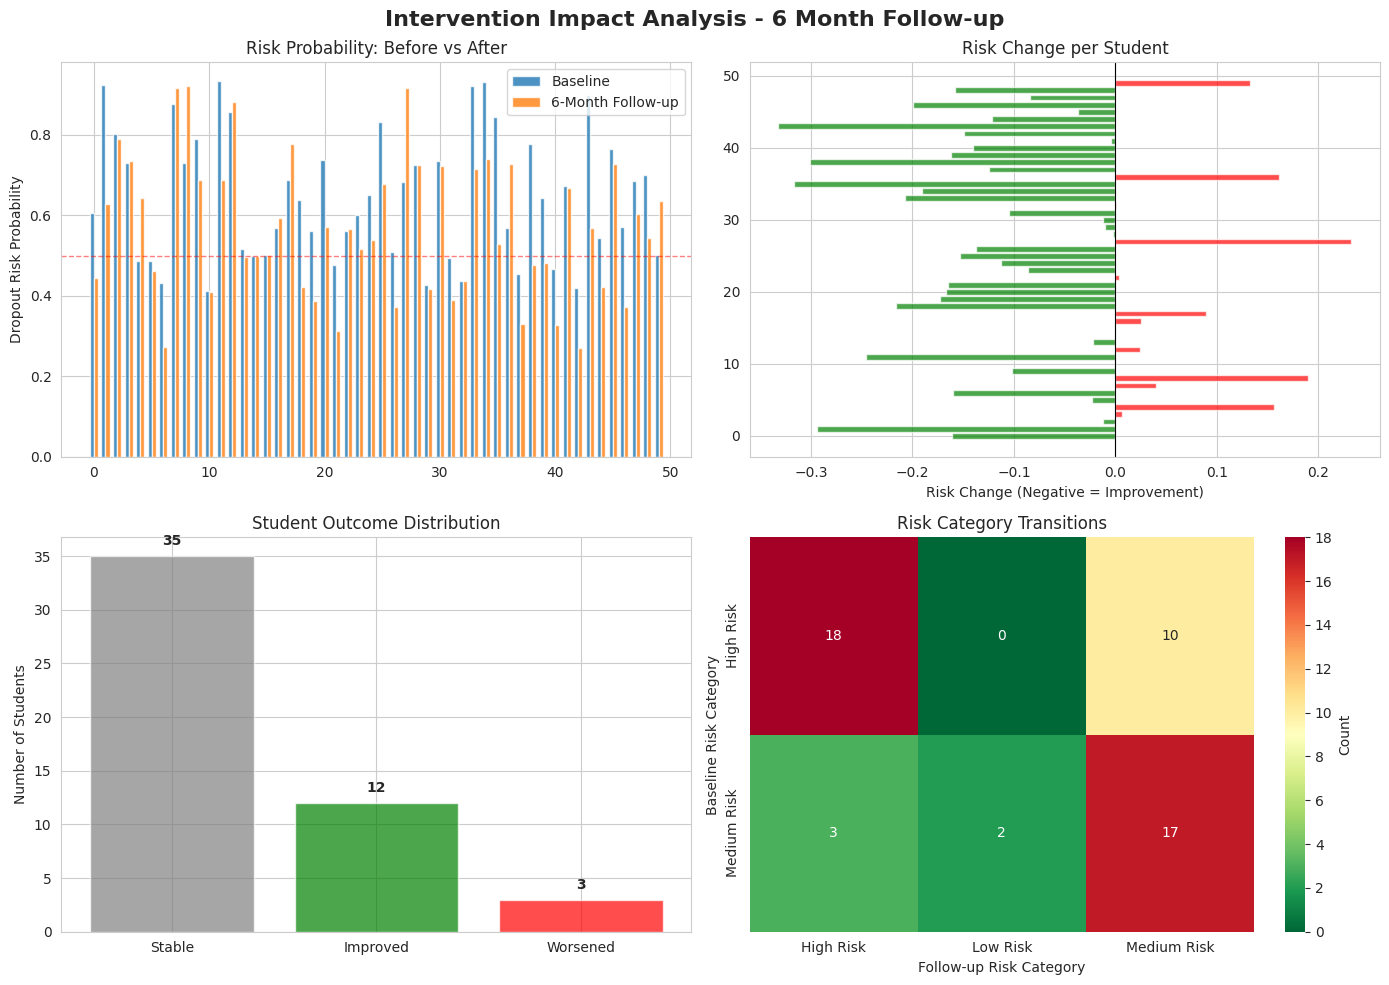

✓ Risk distribution comparison saved


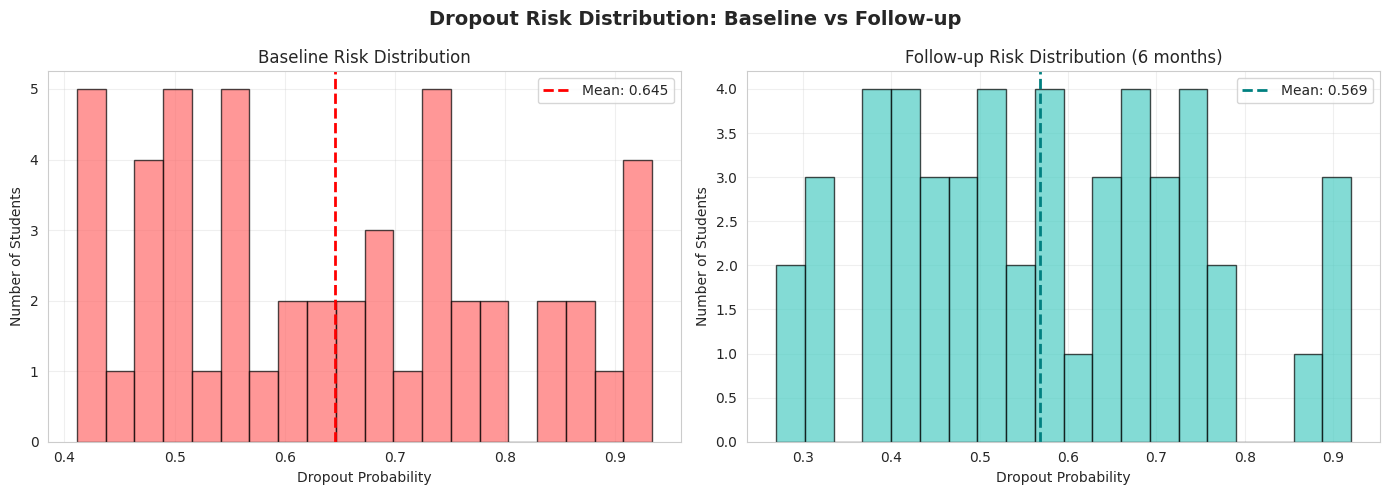

In [24]:
## 11. Generate Visualizations

print("Creating intervention impact visualizations...\n")

fig = plot_intervention_impact(comparison_df)
plt.tight_layout()
plt.savefig(INTERVENTION_DATA_PATH / 'intervention_impact_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved to: intervention_impact_analysis.png")
plt.show()

# Additional visualization: Risk distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dropout Risk Distribution: Baseline vs Follow-up', fontsize=14, fontweight='bold')

# Baseline distribution
axes[0].hist(comparison_df['baseline_risk_prob'], bins=20, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0].axvline(comparison_df['baseline_risk_prob'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {comparison_df["baseline_risk_prob"].mean():.3f}')
axes[0].set_xlabel('Dropout Probability')
axes[0].set_ylabel('Number of Students')
axes[0].set_title('Baseline Risk Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Follow-up distribution
axes[1].hist(comparison_df['followup_risk_prob'], bins=20, color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[1].axvline(comparison_df['followup_risk_prob'].mean(), color='teal', linestyle='--', linewidth=2, label=f'Mean: {comparison_df["followup_risk_prob"].mean():.3f}')
axes[1].set_xlabel('Dropout Probability')
axes[1].set_ylabel('Number of Students')
axes[1].set_title('Follow-up Risk Distribution (6 months)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(INTERVENTION_DATA_PATH / 'risk_distribution_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Risk distribution comparison saved")
plt.show()

In [25]:
## 12. Generate Final Report

print_intervention_report(metrics, comparison_df)

# Additional analysis: Category transitions
print("\n" + "="*70)
print("RISK CATEGORY TRANSITIONS".center(70))
print("="*70)

transition_matrix = pd.crosstab(comparison_df['baseline_risk_category'], 
                                comparison_df['followup_risk_category'],
                                margins=True)
print("\nHow many students moved between risk categories:")
print(transition_matrix)

print("\n" + "="*70)
print("KEY INSIGHTS".center(70))
print("="*70)

high_risk_baseline = len(comparison_df[comparison_df['baseline_risk_category'] == 'High Risk'])
high_risk_followup = len(comparison_df[comparison_df['followup_risk_category'] == 'High Risk'])

print(f"\n📊 Risk Category Movement:")
print(f"  High Risk students at baseline: {high_risk_baseline}")
print(f"  High Risk students at follow-up: {high_risk_followup}")
print(f"  Change: {high_risk_followup - high_risk_baseline:+d} ({'improvement' if high_risk_followup < high_risk_baseline else 'concern'})")

downgraded = len(comparison_df[(comparison_df['baseline_risk_category'] == 'High Risk') & 
                               (comparison_df['followup_risk_category'] != 'High Risk')])
print(f"\n✅ Students who moved out of High Risk: {downgraded}")

escalated = len(comparison_df[(comparison_df['baseline_risk_category'] != 'High Risk') & 
                              (comparison_df['followup_risk_category'] == 'High Risk')])
print(f"⚠️  Students who moved into High Risk: {escalated}")

# Save metrics to JSON
metrics_path = INTERVENTION_DATA_PATH / 'intervention_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump({k: (v.tolist() if hasattr(v, 'tolist') else float(v)) if isinstance(v, (np.floating, np.integer)) else v 
               for k, v in metrics.items()}, f, indent=2)

print(f"\n✓ Metrics saved to: {metrics_path}")
print("\n" + "="*70)

                 INTERVENTION IMPACT ANALYSIS REPORT                  

📊 SUMMARY
  Total students in intervention group: 50
  Analysis period: Baseline → 6-Month Follow-up

✅ IMPROVEMENT OUTCOMES
  Students improved:   12 ( 24.0%)
  Students worsened:    3 (  6.0%)
  Students stable:     35 ( 70.0%)

📈 RISK METRICS
  Average baseline risk:    0.645
  Average follow-up risk:   0.569
  Mean risk change:         -0.0765
  Median risk change:       -0.0940

🎯 CONCLUSION: Interventions appear EFFECTIVE - average risk decreased


                      RISK CATEGORY TRANSITIONS                       

How many students moved between risk categories:
followup_risk_category  High Risk  Low Risk  Medium Risk  All
baseline_risk_category                                       
High Risk                      18         0           10   28
Medium Risk                     3         2           17   22
All                            21         2           27   50

                             KEY INSI

## 7. Save Intervention Tracking Data

In [26]:
# Save baseline data for intervention recipients
baseline_path = INTERVENTION_DATA_PATH / 'intervention_recipients_baseline.csv'
df_intervention_recipients.to_csv(baseline_path, index=False)

print(f"✓ Baseline intervention data saved to: {baseline_path}")
print(f"\nData structure:")
print(f"  - Total intervention recipients: {len(df_intervention_recipients)}")
print(f"  - Features tracked: {len(df_intervention_recipients.columns)}")
print(f"\nNext steps:")
print(f"  1. Collect 6-month follow-up data for these students")
print(f"  2. Update the template: {template_path}")
print(f"  3. Run the comparison analysis")

✓ Baseline intervention data saved to: /home/oriol-ms/IA-Universitat/PAID/PAID-Lab/PW234-PAID-2026-T6-StudentDropout/InterventionData/intervention_recipients_baseline.csv

Data structure:
  - Total intervention recipients: 1319
  - Features tracked: 22

Next steps:
  1. Collect 6-month follow-up data for these students


NameError: name 'template_path' is not defined

## 8. WORKFLOW: When Follow-up Data is Ready

Once you have collected the 6-month follow-up data, follow these steps:

1. **Update the follow-up template CSV** with real data from your students
2. **Load the updated CSV**:
   ```python
   df_followup = pd.read_csv(INTERVENTION_DATA_PATH / 'followup_data_6m.csv')
   ```
3. **Generate predictions** using your XGBoost model on follow-up features
4. **Run comparison analysis** with the `compare_intervention_results()` function
5. **Generate visualizations** with `plot_intervention_impact()`
6. **Review metrics** and determine intervention effectiveness

## Information for Data Collection

**Intervention Recipients Metadata:**

In [ ]:
# Save metadata about intervention tracking
metadata = {
    "analysis_date": pd.Timestamp.now().isoformat(),
    "total_intervention_recipients": len(df_intervention_recipients),
    "analysis_type": "Intervention Impact Assessment",
    "measurement_periods": {
        "baseline": "Pre-intervention assessment",
        "followup": "6 months after intervention start"
    },
    "features_tracked": df_intervention_recipients.columns.tolist(),
    "files_generated": {
        "template": str(template_path),
        "baseline_data": str(baseline_path),
    }
}

metadata_path = INTERVENTION_DATA_PATH / 'metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata saved to: {metadata_path}")
print(json.dumps(metadata, indent=2))

✓ Metadata saved to: /home/oriol-ms/IA-Universitat/PAID/PAID-Lab/PW234-PAID-2026-T6-StudentDropout/InterventionData/metadata.json
{
  "analysis_date": "2026-05-19T19:20:43.654673",
  "total_intervention_recipients": 1319,
  "analysis_type": "Intervention Impact Assessment",
  "measurement_periods": {
    "baseline": "Pre-intervention assessment",
    "followup": "6 months after intervention start"
  },
  "features_tracked": [
    "Hours_Studied",
    "Attendance",
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Sleep_Hours",
    "Previous_Scores",
    "Motivation_Level",
    "Internet_Access",
    "Tutoring_Sessions",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Physical_Activity",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender",
    "Exam_Score",
    "dropout",
    "student_id"
  ],
  "files_generated": {
    "template": "/home/oriol-ms/IA-Univ